# **0. Análisis Exploratorio de los Datos**

**Objetivo:** Visualización de los datos, limpieza y entendimiento de las variables.

---

Juan Pablo Espinosa Maciel | A01646333

In [1]:
# --- Manejo de datos ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pruebas estadísticas básicas (normalidad y QQ-plot) ---
from scipy import stats

# Mostrar todas las columnas al imprimir un DataFrame
pd.set_option('display.max_columns', None)

# Estilo uniforme para todas las gráficas del notebook
sns.set_theme(style='whitegrid')

## **0. Previsualización de los Datos**

In [2]:
# Carga del dataset crudo de enfermedad renal crónica (CKD)
data = pd.read_csv(r'data\raw\ckd.csv')

# Primer vistazo: formato y contenido de cada columna
data.head(10)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,25.0,1.1,142.0,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,54.0,24.0,104.0,4.0,12.4,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,31.0,1.1,NaN,NaN,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,60.0,1.9,NaN,NaN,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,107.0,7.2,114.0,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


Entendiendo cada una de las columnas observamos:
* `age`: Age.

* `bp`: Blood pressure.

* `sg`: Specific gravity.

* `al`: Albumin.

* `su`: Sugar.

* `rbc`: Red blood cells.

* `pc`: Pus cell.

* `pcc`: Pus cell clumps.

* `ba`: Bacteria.

* `bgr`: Blood glucose random.

* `bu`: Blood urea.

* `sc`: Serum creatinine.

* `sod`: Sodium.

* `pot`: Potassium.

* `hemo`: Hemoglobin.

* `pcv`: Packed cell volume.

* `wc`: White blood cell count.

* `rc`: Red blood cell count.

* `htn`: Hypertension.

* `dm`: Diabetes mellitus.

* `cad`: Coronary artery disease.

* `appet`: Appetite.

* `pe`: Pedal edema.

* `ane`: Anemia.

* `class`: Diagnosis.

In [3]:
# Información por cada varaible
informacion = pd.DataFrame({
    'dtype': data.dtypes.astype(str),                       # Tipo con el que pandas leyó la columna
    'n_miss': data.isna().sum(),                            # Cuántos valores faltan
    'pct_miss': (data.isna().mean() * 100).round(2),        # Porcentaje de faltantes
    'unique': data.nunique(),                               # Cuántos valores distintos tiene (indica si es continua o discreta)
})

informacion

,dtype,n_miss,pct_miss,unique
id,int64,0,0.00,400
age,float64,9,2.25,76
bp,float64,12,3.00,10
sg,float64,47,11.75,5
al,float64,46,11.50,6
su,float64,49,12.25,6
rbc,object,152,38.00,2
pc,object,65,16.25,2
pcc,object,4,1.00,2
ba,object,4,1.00,2


**Observaciones de los datos:**

1. `id` tiene 400 valores únicos: es un identificador, **no una variable**. Se elimina.

2. `pcv`, `wc` y `rc` aparecen como `object` aunque deberían ser **numéricas**. Hay algún carácter extraño dentro de la columna que impide a pandas leerlas como número.

3. `classification` reporta **3 valores únicos** cuando el diagnóstico solo puede ser `ckd` o `notckd`. Lo mismo ocurre con `dm` (5 niveles) y `cad` (3 niveles).

4. Los faltantes no son menores: `rbc` 38%, `rc` 32.5%, `wc` 26.25%.

## **1. Limpieza de los Datos**

In [4]:
# Elimina 'id' porque es un identificador, no una variable del problema
df = data.drop(columns = 'id')

# Limpia el texto de TODAS las columnas categóricas:
obj_cols = df.columns[df.dtypes == object]
for c in obj_cols:
    df[c] = df[c].str.strip().str.lower().replace({'?': np.nan,
                                                   '': np.nan})

# Convierten a número las tres columnas que venían mal tipadas.
df['pcv'] = pd.to_numeric(df['pcv'], errors= 'coerce')
df['wc'] = pd.to_numeric(df['wc'], errors= 'coerce')
df['rc'] = pd.to_numeric(df['rc'], errors= 'coerce')

df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [5]:
# Verificación
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [6]:
# Comprobación de que la limpieza de texto funcionó: 
#       Cada variable categórica debe tener únicamente sus niveles reales
for c in df.columns[df.dtypes == object]:
    print(f'{c:16s} -> {df[c].dropna().unique()}')

rbc              -> ['normal' 'abnormal']
pc               -> ['normal' 'abnormal']
pcc              -> ['notpresent' 'present']
ba               -> ['notpresent' 'present']
htn              -> ['yes' 'no']
dm               -> ['yes' 'no']
cad              -> ['no' 'yes']
appet            -> ['good' 'poor']
pe               -> ['no' 'yes']
ane              -> ['no' 'yes']
classification   -> ['ckd' 'notckd']


**Resultado de la limpieza:**

- `classification` quedó con 2 niveles (`ckd`, `notckd`); `dm` y `cad` con 2 cada uno.

- `pcv`, `wc` y `rc` ya son `float64`. El carácter que las ensuciaba era `'\t?'`, que ahora se cuenta correctamente como dato faltante.

- El dataset quedó en **400 filas × 25 columnas**, eliminando la columna de `id`.

## **2. Clasificación de Variables**

Se separan las variables en **continuas** y **discretas**. Esta división es la decisión más importante del EDA, porque una **Red Bayesiana Gaussiana solo admite variables continuas**.

In [7]:
# Se listan los valores únicos de cada variable.
#    Sirve para ver de un vistazo cuáles tienen pocos niveles (discretas) y cuáles tienen muchos valores distintos (continuas).
values = []

for c in df.columns:
    v = df[c].unique()
    values.append(v)

# Cada fila de la tabla corresponde a una variable
tabla_valores = pd.DataFrame(values, index = df.columns)
tabla_valores.replace({np.nan: ''})

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146
age,48.0,7.0,62.0,51.0,60.0,68.0,24.0,52.0,53.0,50.0,63.0,40.0,47.0,61.0,21.0,42.0,75.0,69.0,,73.0,70.0,65.0,76.0,72.0,82.0,46.0,45.0,35.0,54.0,11.0,59.0,67.0,15.0,55.0,44.0,26.0,64.0,56.0,5.0,74.0,38.0,58.0,71.0,34.0,17.0,12.0,43.0,41.0,57.0,8.0,39.0,66.0,81.0,14.0,27.0,83.0,30.0,4.0,3.0,6.0,32.0,80.0,49.0,90.0,78.0,19.0,2.0,33.0,36.0,37.0,23.0,25.0,20.0,29.0,28.0,22.0,79.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
bp,80.0,50.0,70.0,90.0,,100.0,60.0,110.0,140.0,180.0,120.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
sg,1.02,1.01,1.005,1.015,,1.025,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
al,1.0,4.0,2.0,3.0,0.0,,5.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
su,0.0,3.0,4.0,1.0,,2.0,5.0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
rbc,,normal,abnormal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
pc,normal,abnormal,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
pcc,notpresent,present,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ba,notpresent,present,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
bgr,121.0,,423.0,117.0,106.0,74.0,100.0,410.0,138.0,70.0,490.0,380.0,208.0,98.0,157.0,76.0,99.0,114.0,263.0,173.0,95.0,108.0,156.0,264.0,123.0,93.0,107.0,159.0,140.0,171.0,270.0,92.0,137.0,204.0,79.0,207.0,124.0,144.0,91.0,162.0,246.0,253.0,141.0,182.0,86.0,150.0,146.0,425.0,112.0,250.0,360.0,163.0,129.0,133.0,102.0,158.0,165.0,132.0,104.0,127.0,415.0,169.0,251.0,109.0,280.0,210.0,219.0,295.0,94.0,172.0,101.0,298.0,153.0,88.0,226.0,143.0,115.0,89.0,297.0,233.0,294.0,323.0,125.0,90.0,308.0,118.0,224.0,128.0,122.0,214.0,213.0,268.0,256.0,84.0,105.0,288.0,139.0,78.0,273.0,242.0,424.0,303.0,148.0,160.0,192.0,307.0,220.0,447.0,309.0,22.0,111.0,261.0,215.0,234.0,131.0,352.0,80.0,239.0,110.0,130.0,184.0,252.0,113.0,230.0,341.0,255.0,103.0,238.0,248.0,120.0,241.0,269.0,201.0,203.0,463.0,176.0,82.0,119.0,97.0,96.0,81.0,116.0,134.0,85.0,83.0,87.0,75.0


In [8]:
# CONTINUAS: variables numéricas que pueden tomar cualquier valor dentro de un rango.
continuas = ['age', 'bp', 'sg', 'al', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

# DISCRETAS: variables con un número reducido de niveles.
discretas = ['su', 'rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

df_continuas = df[continuas]

df_continuas

,age,bp,sg,al,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,48.0,80.0,1.020,1.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9


In [9]:
# Cuántos datos válidos tiene realmente cada variable continua
df_continuas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   bgr     356 non-null    float64
 5   bu      381 non-null    float64
 6   sc      383 non-null    float64
 7   sod     313 non-null    float64
 8   pot     312 non-null    float64
 9   hemo    348 non-null    float64
 10  pcv     329 non-null    float64
 11  wc      294 non-null    float64
 12  rc      269 non-null    float64
dtypes: float64(13)
memory usage: 40.8 KB


In [10]:
# Cuántos valores distintos  tiene cada variable discreta
print('\nNiveles de las variables discretas:')
for v in discretas:
    print(f'  {v:16s} {df[v].nunique()} valores')


Niveles de las variables discretas:
  su               6 valores
  rbc              2 valores
  pc               2 valores
  pcc              2 valores
  ba               2 valores
  htn              2 valores
  dm               2 valores
  cad              2 valores
  appet            2 valores
  pe               2 valores
  ane              2 valores
  classification   2 valores


**Criterio usado:**

| Grupo | Variables | Justificación |
|---|---|---|
| **Continuas (10)** | `age`, `bp`, `sg`, `al`, `bgr`, `bu`, `sc`, `sod`, `pot`, `hemo`, `pcv`, `wc`, `rc` | Mediciones de laboratorio con muchos valores distintos. |
| **Discretas (15)** | `su` + las 10 categóricas + `classification` |  |

**Consecuencia para el modelo:** solo **10 de las 25 variables** pueden entrar directamente a una Red Bayesiana Gaussiana. Las 15 discretas requieren un tratamiento distinto (red híbrida o codificación). Las variables continuas son:

* `age`: Age.

* `bp`: Blood pressure.

* `sg`: Specific gravity.

* `al`: Albumin.

* `bgr`: Blood glucose random.

* `bu`: Blood urea.

* `sc`: Serum creatinine.

* `sod`: Sodium.

* `pot`: Potassium.

* `hemo`: Hemoglobin.

* `pcv`: Packed cell volume.

* `wc`: White blood cell count.

* `rc`: Red blood cell count.

## **3. Análisis de Datos Continuos**

Se revisa el comportamiento individual de cada variable continua: su distribución,
su dispersión y qué tan lejos está de una distribución normal.

In [11]:
# Analizamos frecuencia, media, desviación, cuartiles y sesgo y curtosis.
resumen = df[continuas].describe().T

resumen['sesgo'] = df[continuas].skew()             # Sesgo: Nos dice la asimetría de los datos continuos
resumen['curtosis'] = df[continuas].kurt()          # Curtosis: Mientras más cercano a cero, su comportamiento es más cercano a la normal

resumen.round(2)

,count,mean,std,min,25%,50%,75%,max,sesgo,curtosis
age,391.0,51.48,17.17,2.0,42.00,55.00,64.50,90.00,-0.67,0.06
bp,388.0,76.47,13.68,50.0,70.00,80.00,80.00,180.00,1.61,8.65
sg,353.0,1.02,0.01,1.0,1.01,1.02,1.02,1.02,-0.17,-1.14
al,354.0,1.02,1.35,0.0,0.00,0.00,2.00,5.00,1.00,-0.38
bgr,356.0,148.04,79.28,22.0,99.00,121.00,163.00,490.00,2.01,4.23
bu,381.0,57.43,50.50,1.5,27.00,42.00,66.00,391.00,2.63,9.35
sc,383.0,3.07,5.74,0.4,0.90,1.30,2.80,76.00,7.51,79.30
sod,313.0,137.53,10.41,4.5,135.00,138.00,142.00,163.00,-7.00,85.53
pot,312.0,4.63,3.19,2.5,3.80,4.40,4.90,47.00,11.58,142.51
hemo,348.0,12.53,2.91,3.1,10.30,12.65,15.00,17.80,-0.34,-0.47


**Qué observar:** un sesgo cercano a 0 y una curtosis cercana a 0 indican una variable
parecida a la normal. Valores muy grandes (como los de `pot` o `sod`) son señal de que hay
**datos extremos** jalando la distribución.

""


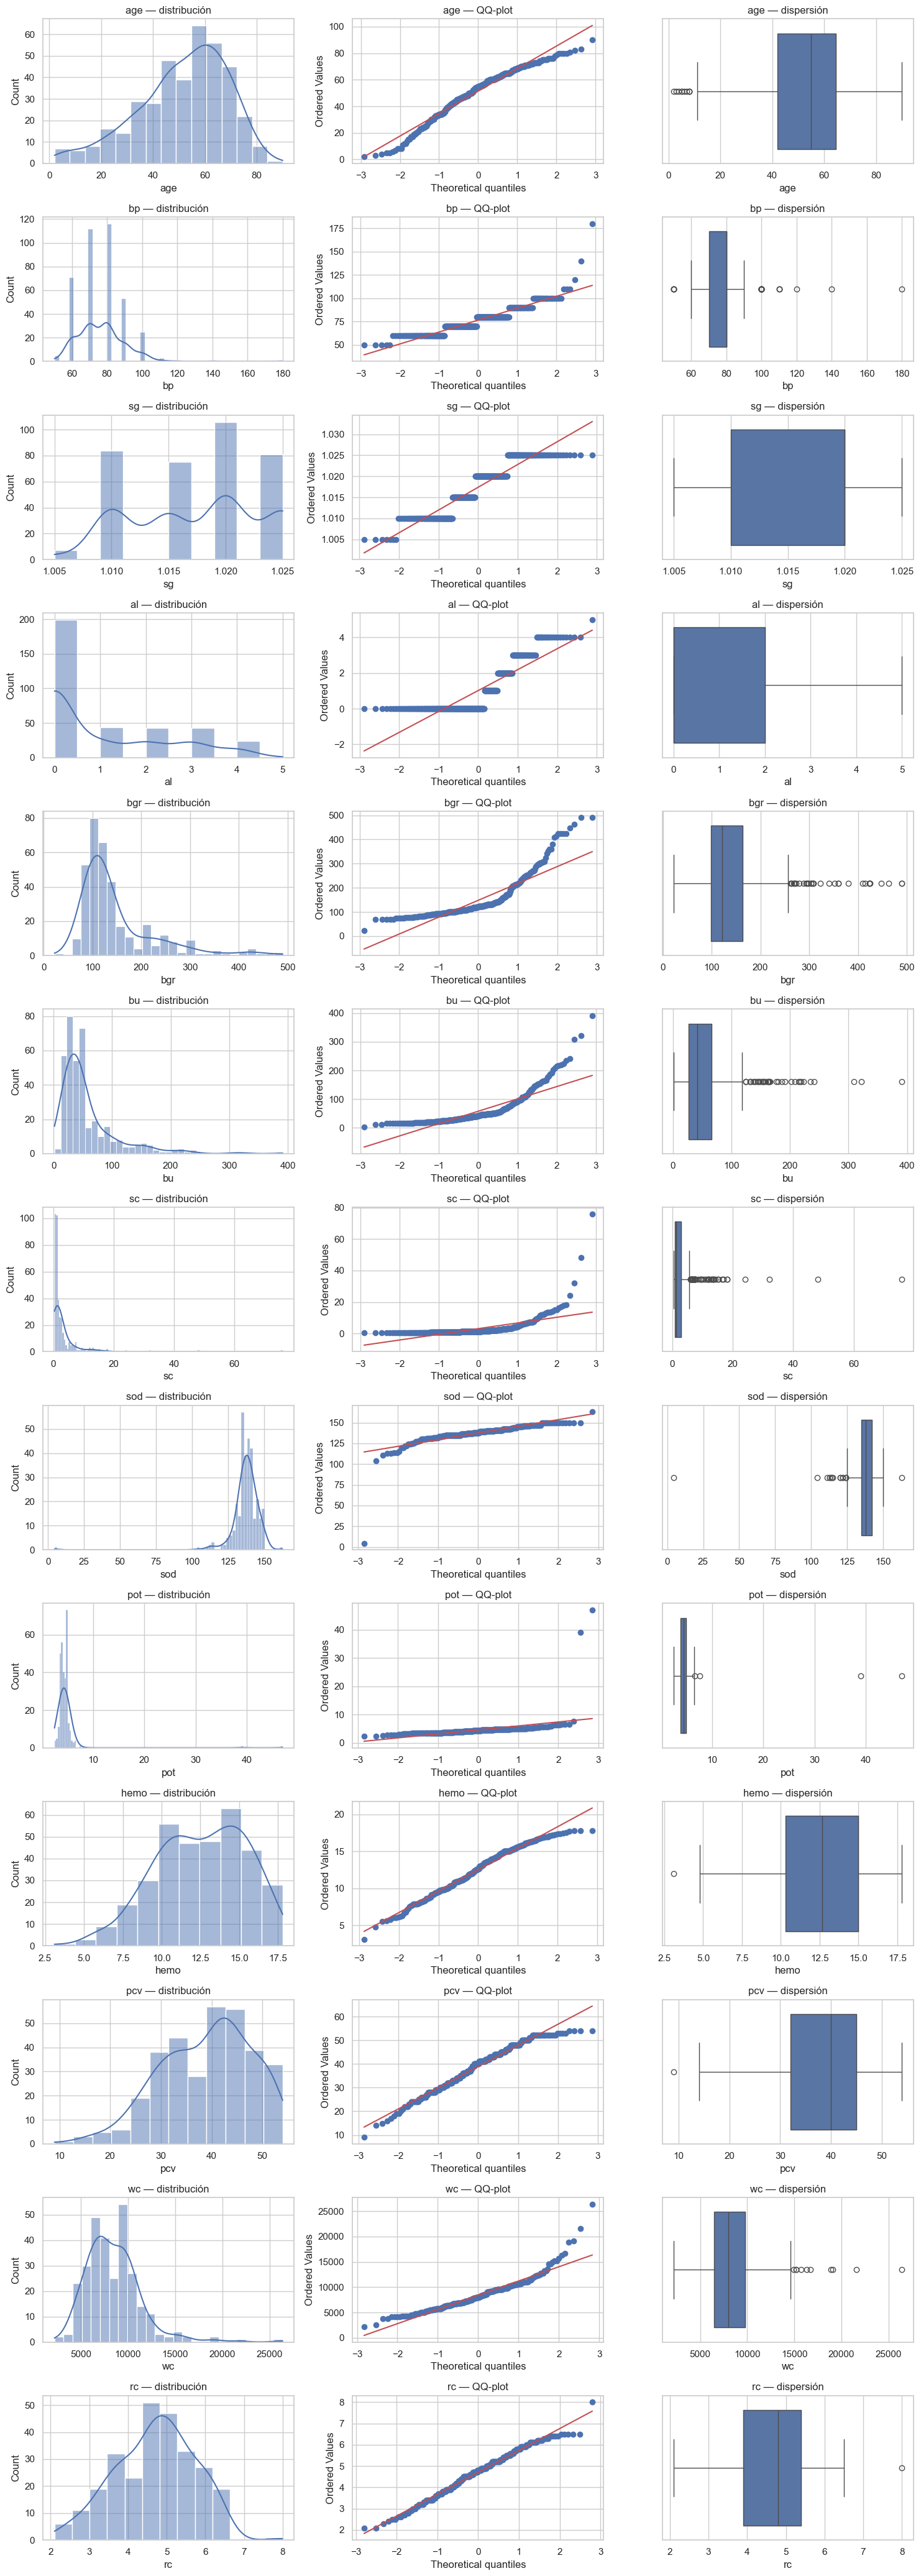

In [12]:
# Para cada variable continua se grafican tres vistas complementarias:
#   1) Histograma
#   2) QQ-plot (Comparado con una Normal teórica)
#   3) Boxplot
fig, axes = plt.subplots(len(continuas), 3, figsize=(15, 3.2*len(continuas)))
norm = []

for i, v in enumerate(continuas):
    s = df[v].dropna()
    sns.histplot(s, kde=True, ax=axes[i,0]); axes[i,0].set_title(f'{v} — distribución')
    stats.probplot(s, dist='norm', plot=axes[i,1]); axes[i,1].set_title(f'{v} — QQ-plot')
    sns.boxplot(x=s, ax=axes[i,2]); axes[i,2].set_title(f'{v} — dispersión')
    
plt.tight_layout()
display(pd.DataFrame(norm))

**Observaciones del análisis individual:**

- `age`, `hemo`, `pcv` y `rc` se ven razonablemente simétricas (sesgo entre −0.7 y 0).

- `sc`, `bu`, `bgr` y `wc` tienen **cola larga a la derecha**: unos pocos pacientes con valores muy altos.

- `pot` (sesgo 11.6) y `sod` (sesgo −7.0) son casos extremos.

### **3.1 Comparación de escalas**

Las variables continuas están en unidades muy distintas (`wc` ronda los 8000 y `rc` el 4.7).
Para poder verlas en una misma gráfica se estandarizan.

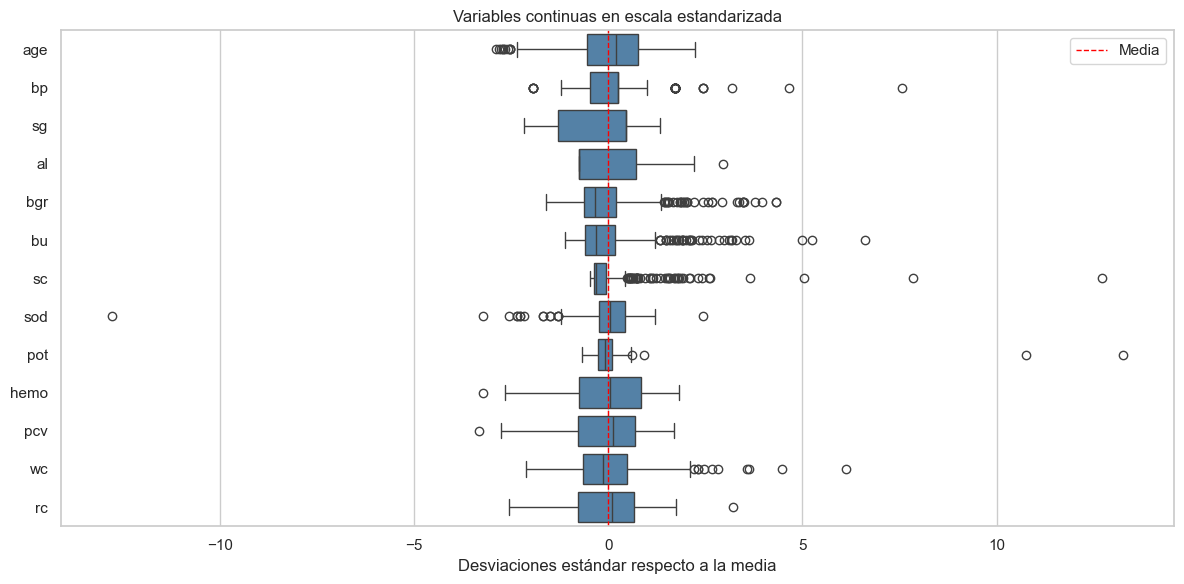

In [13]:
# Estandarización (z-score): a cada valor se le resta la media y se divide entre la desviación estándar. 
z = (df[continuas] - df[continuas].mean()) / df[continuas].std()

plt.figure(figsize=(12, 6))
sns.boxplot(data=z, orient='h', color='steelblue')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Media')
plt.xlabel('Desviaciones estándar respecto a la media')
plt.title('Variables continuas en escala estandarizada')
plt.legend()
plt.tight_layout()
plt.show()

Las variables con muchos puntos alejados hacia la derecha (`bp`, `sc`, `bu`, `bgr`, `wc`) son las de cola pesada, o `sod` con cola hacia la izquerda. Las cajas que se ven centradas y simétricas (`age`, `hemo`, `pcv`, `rc`) son las más cercanas al supuesto gaussiano.

### **3.2 Comportamiento de las continuas según el diagnóstico**

C:\Users\juane\AppData\Local\Temp\ipykernel_24892\2052424361.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=v, hue='classification', fill=True, alpha=0.4, ax=axes[i])


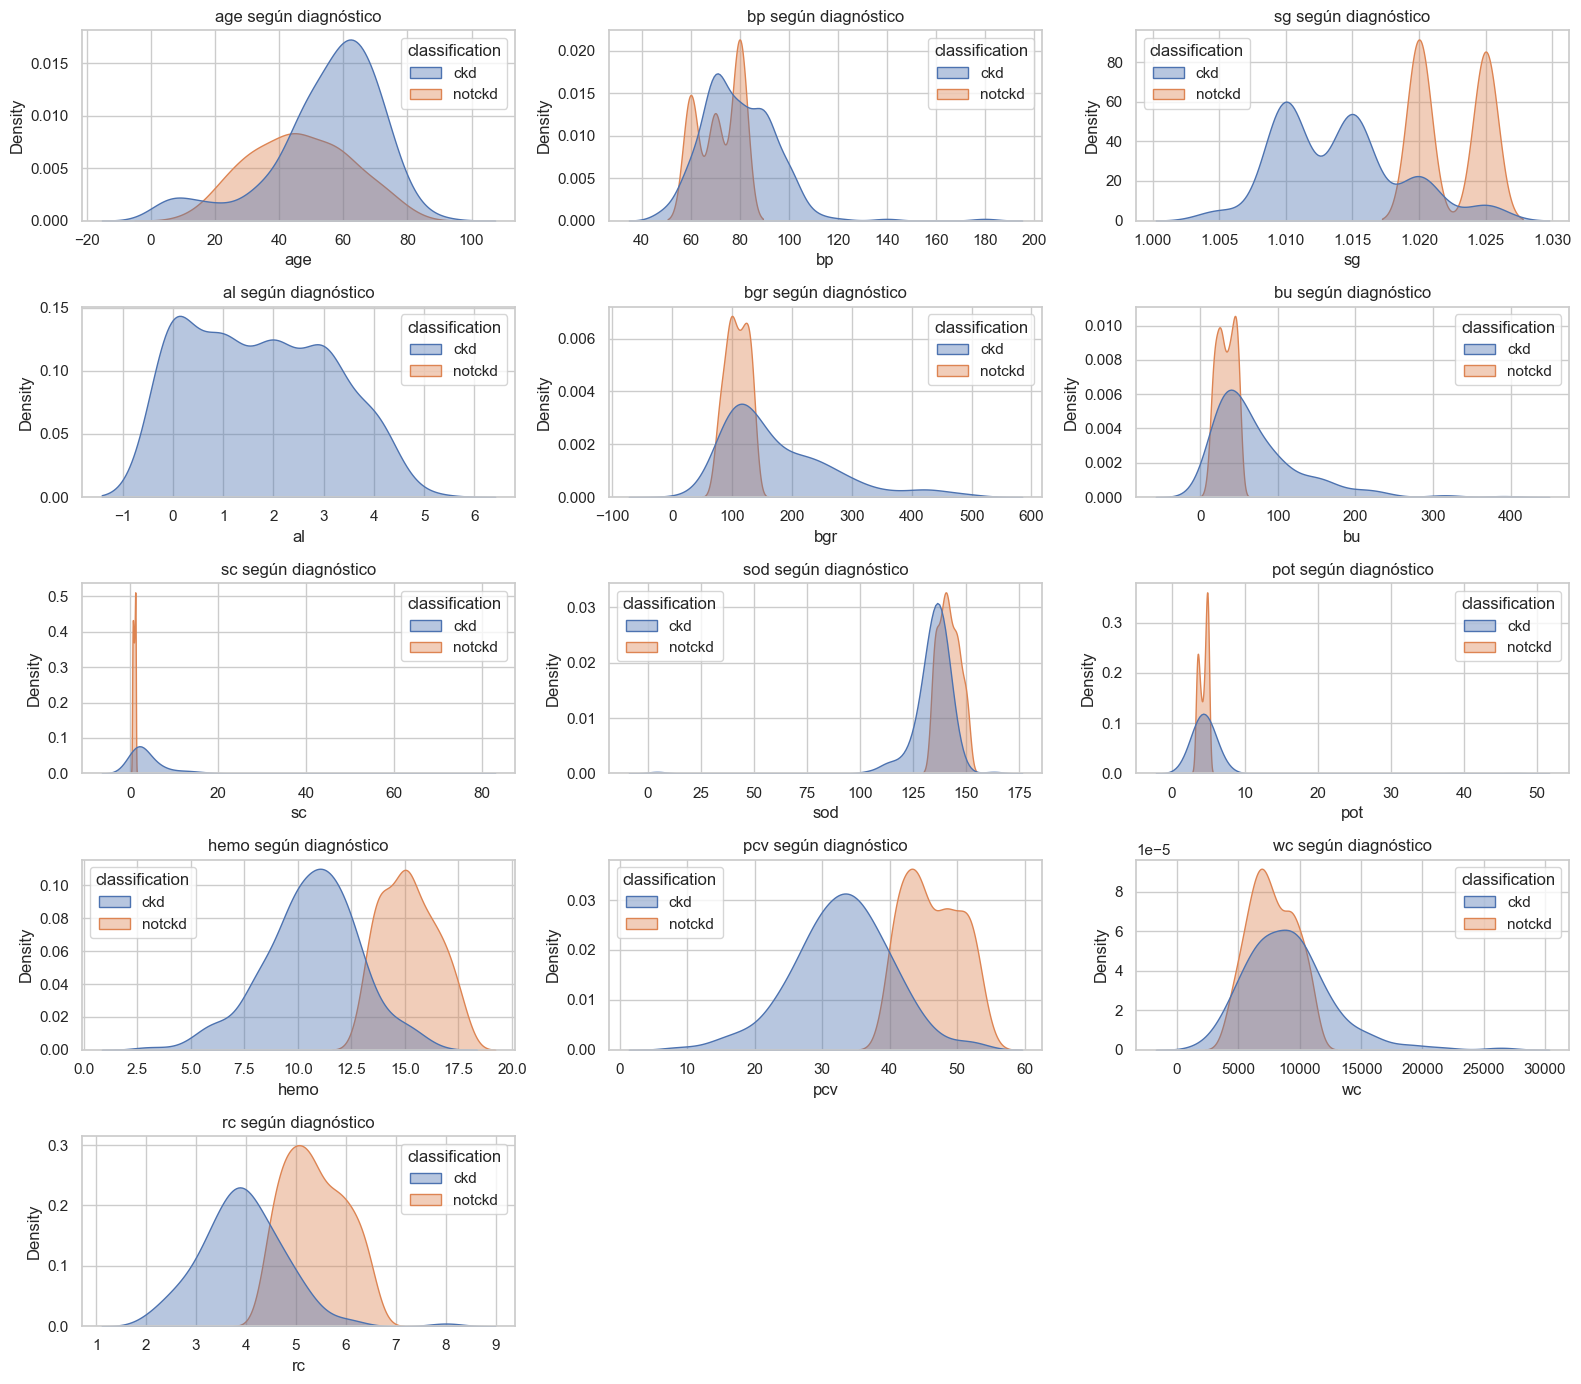

In [15]:
# Densidad de cada variable continua separando enfermos (ckd) de sanos (notckd).
# Permite ver si la variable distingue entre los dos grupos.
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.ravel()

for i, v in enumerate(continuas):
    sns.kdeplot(data=df, x=v, hue='classification', fill=True, alpha=0.4, ax=axes[i])
    axes[i].set_title(f'{v} según diagnóstico')

# Se apagan los recuadros sobrantes (10 variables en una malla de 12)
for j in range(len(continuas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

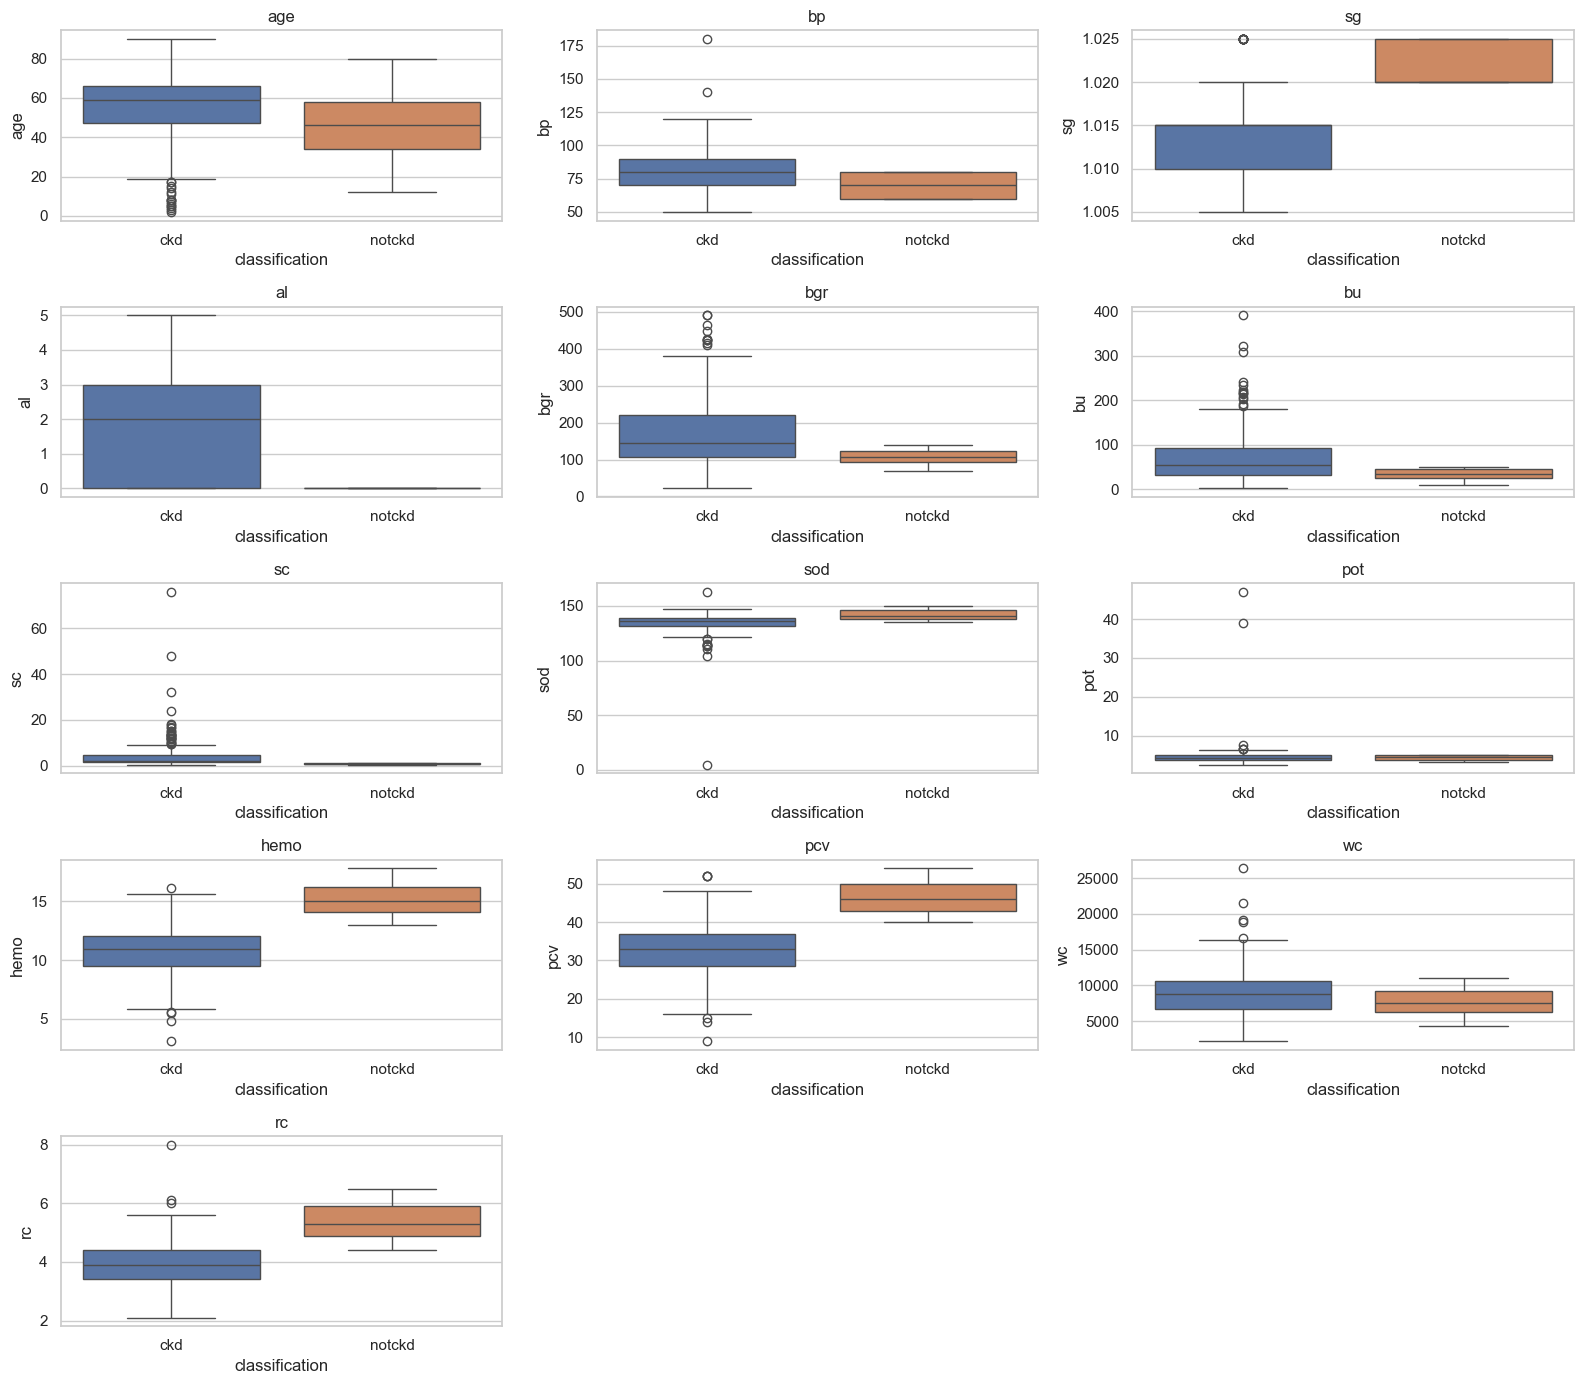

In [16]:
# La misma comparación con boxplots
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.ravel()

for i, v in enumerate(continuas):
    sns.boxplot(data=df, x='classification', y=v, ax=axes[i],
                hue='classification', legend=False)
    axes[i].set_title(v)

for j in range(len(continuas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# Comparación numérica: media de cada variable continua por grupo
medias = df.groupby('classification')[continuas].mean().T
medias['diferencia'] = medias['ckd'] - medias['notckd']

medias.round(2)

classification,ckd,notckd,diferencia
age,54.54,46.52,8.02
bp,79.62,71.35,8.27
sg,1.01,1.02,-0.01
al,1.72,0.00,1.72
bgr,175.42,107.72,67.70
bu,72.39,32.80,39.59
sc,4.41,0.87,3.55
sod,133.90,141.73,-7.83
pot,4.88,4.34,0.54
hemo,10.65,15.19,-4.54


**Observaciones clave:**

- Varias variables muestran **dos picos separados** al graficar ambos grupos juntos. Eso explica buena parte de la "no normalidad" detectada en la sección 3: **se están mezclando dos poblaciones distintas**.

- `hemo`, `pcv` y `rc` son claramente más bajas en los pacientes con `ckd` (anemia asociada a la enfermedad renal).

- `sc`, `bu` y `bgr` son más altas en los enfermos, como se espera clínicamente.

- Esto sugiere que, **condicionando por el diagnóstico**, el supuesto gaussiano podría cumplirse mucho mejor que sobre el conjunto completo.

## **4. Análisis de Datos Discretos**

Las 15 variables discretas no entran a una Red Bayesiana Gaussiana pura, pero contienen
información clínica relevante y ayudan a entender el dataset.

In [18]:
# Dentro de las discretas conviven dos formatos. Esta separación es SOLO para graficar:
discretas_num = ['su']                         # numéricas con pocos niveles
discretas_cat = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm',
                 'cad', 'appet', 'pe', 'ane', 'classification']  # categóricas de texto

# Tabla de frecuencias de cada variable discreta (incluye los faltantes)
for v in discretas:
    print(f'--- {v} ---')
    print(df[v].value_counts(dropna=False).to_string())
    print()

--- su ---
su
0.0    290
NaN     49
2.0     18
3.0     14
4.0     13
1.0     13
5.0      3

--- rbc ---
rbc
normal      201
NaN         152
abnormal     47

--- pc ---
pc
normal      259
abnormal     76
NaN          65

--- pcc ---
pcc
notpresent    354
present        42
NaN             4

--- ba ---
ba
notpresent    374
present        22
NaN             4

--- htn ---
htn
no     251
yes    147
NaN      2

--- dm ---
dm
no     261
yes    137
NaN      2

--- cad ---
cad
no     364
yes     34
NaN      2

--- appet ---
appet
good    317
poor     82
NaN       1

--- pe ---
pe
no     323
yes     76
NaN      1

--- ane ---
ane
no     339
yes     60
NaN      1

--- classification ---
classification
ckd       250
notckd    150



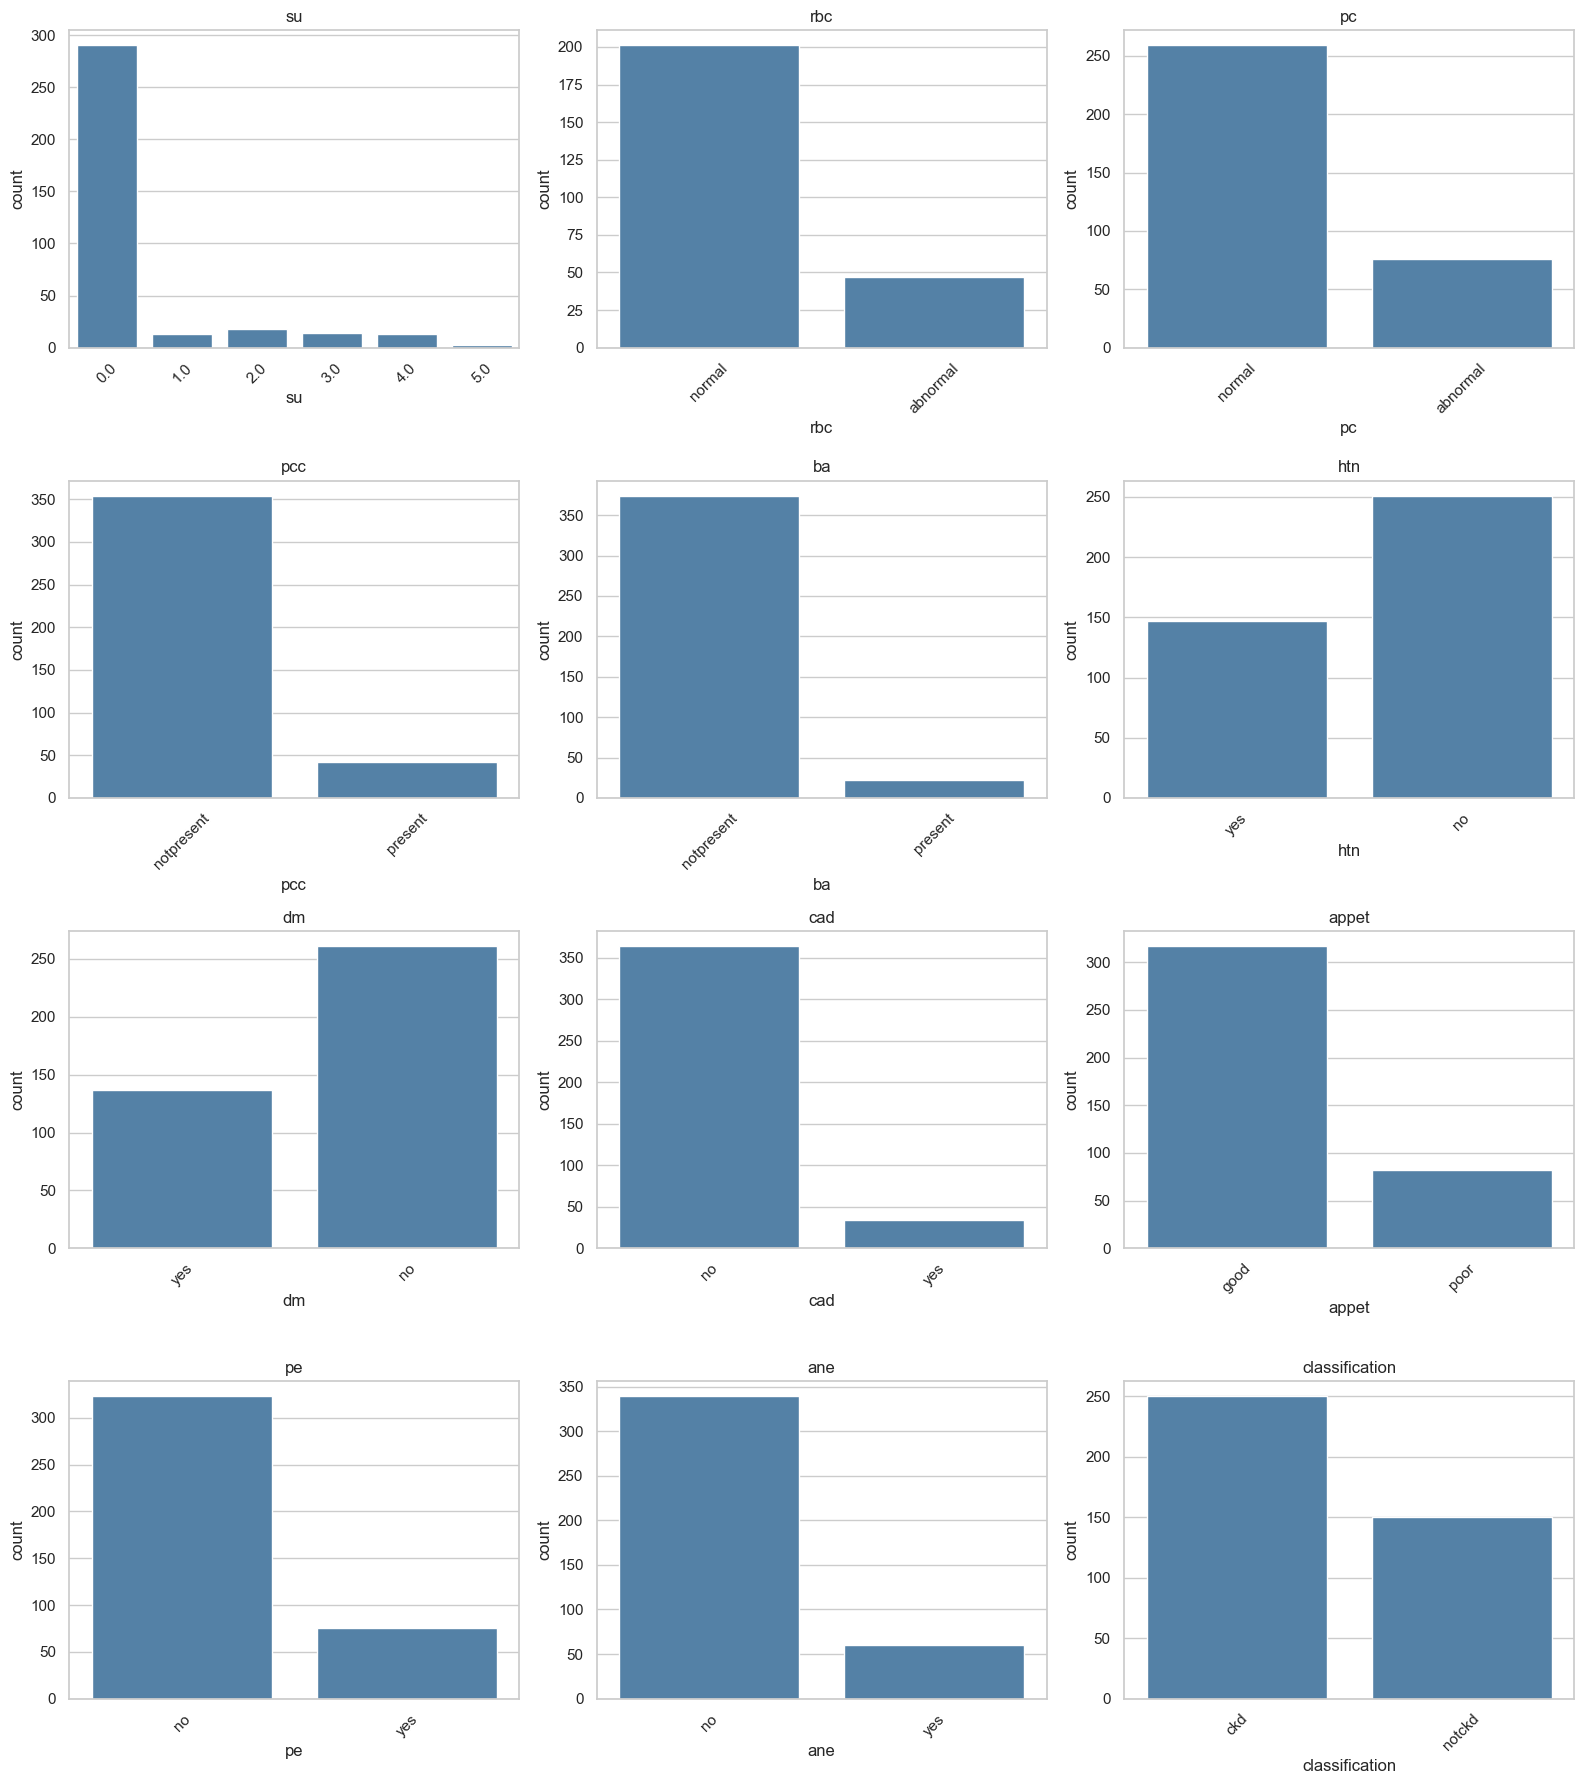

In [20]:
# Gráfica de barras de las variables discretas
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.ravel()

for i, v in enumerate(discretas):
    sns.countplot(data=df, x=v, ax=axes[i], color='steelblue')
    axes[i].set_title(v)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observaciones clave:**

- `classification` está **desbalanceada**: 250 `ckd` contra 150 `notckd` (62.5% / 37.5%).

- `bp` se concentra en 70 y 80 mmHg: la presión se registró redondeada a múltiplos de 10, lo que confirma tratarla como discreta.

- `al` y `su` están fuertemente concentradas en 0 (la mayoría de los pacientes no presenta albúmina ni azúcar en orina).

- `cad`, `pcc` y `ba` tienen niveles muy poco frecuentes, lo que las hace poco informativas por sí solas.

### **4.1 Relación de las discretas con el diagnóstico**

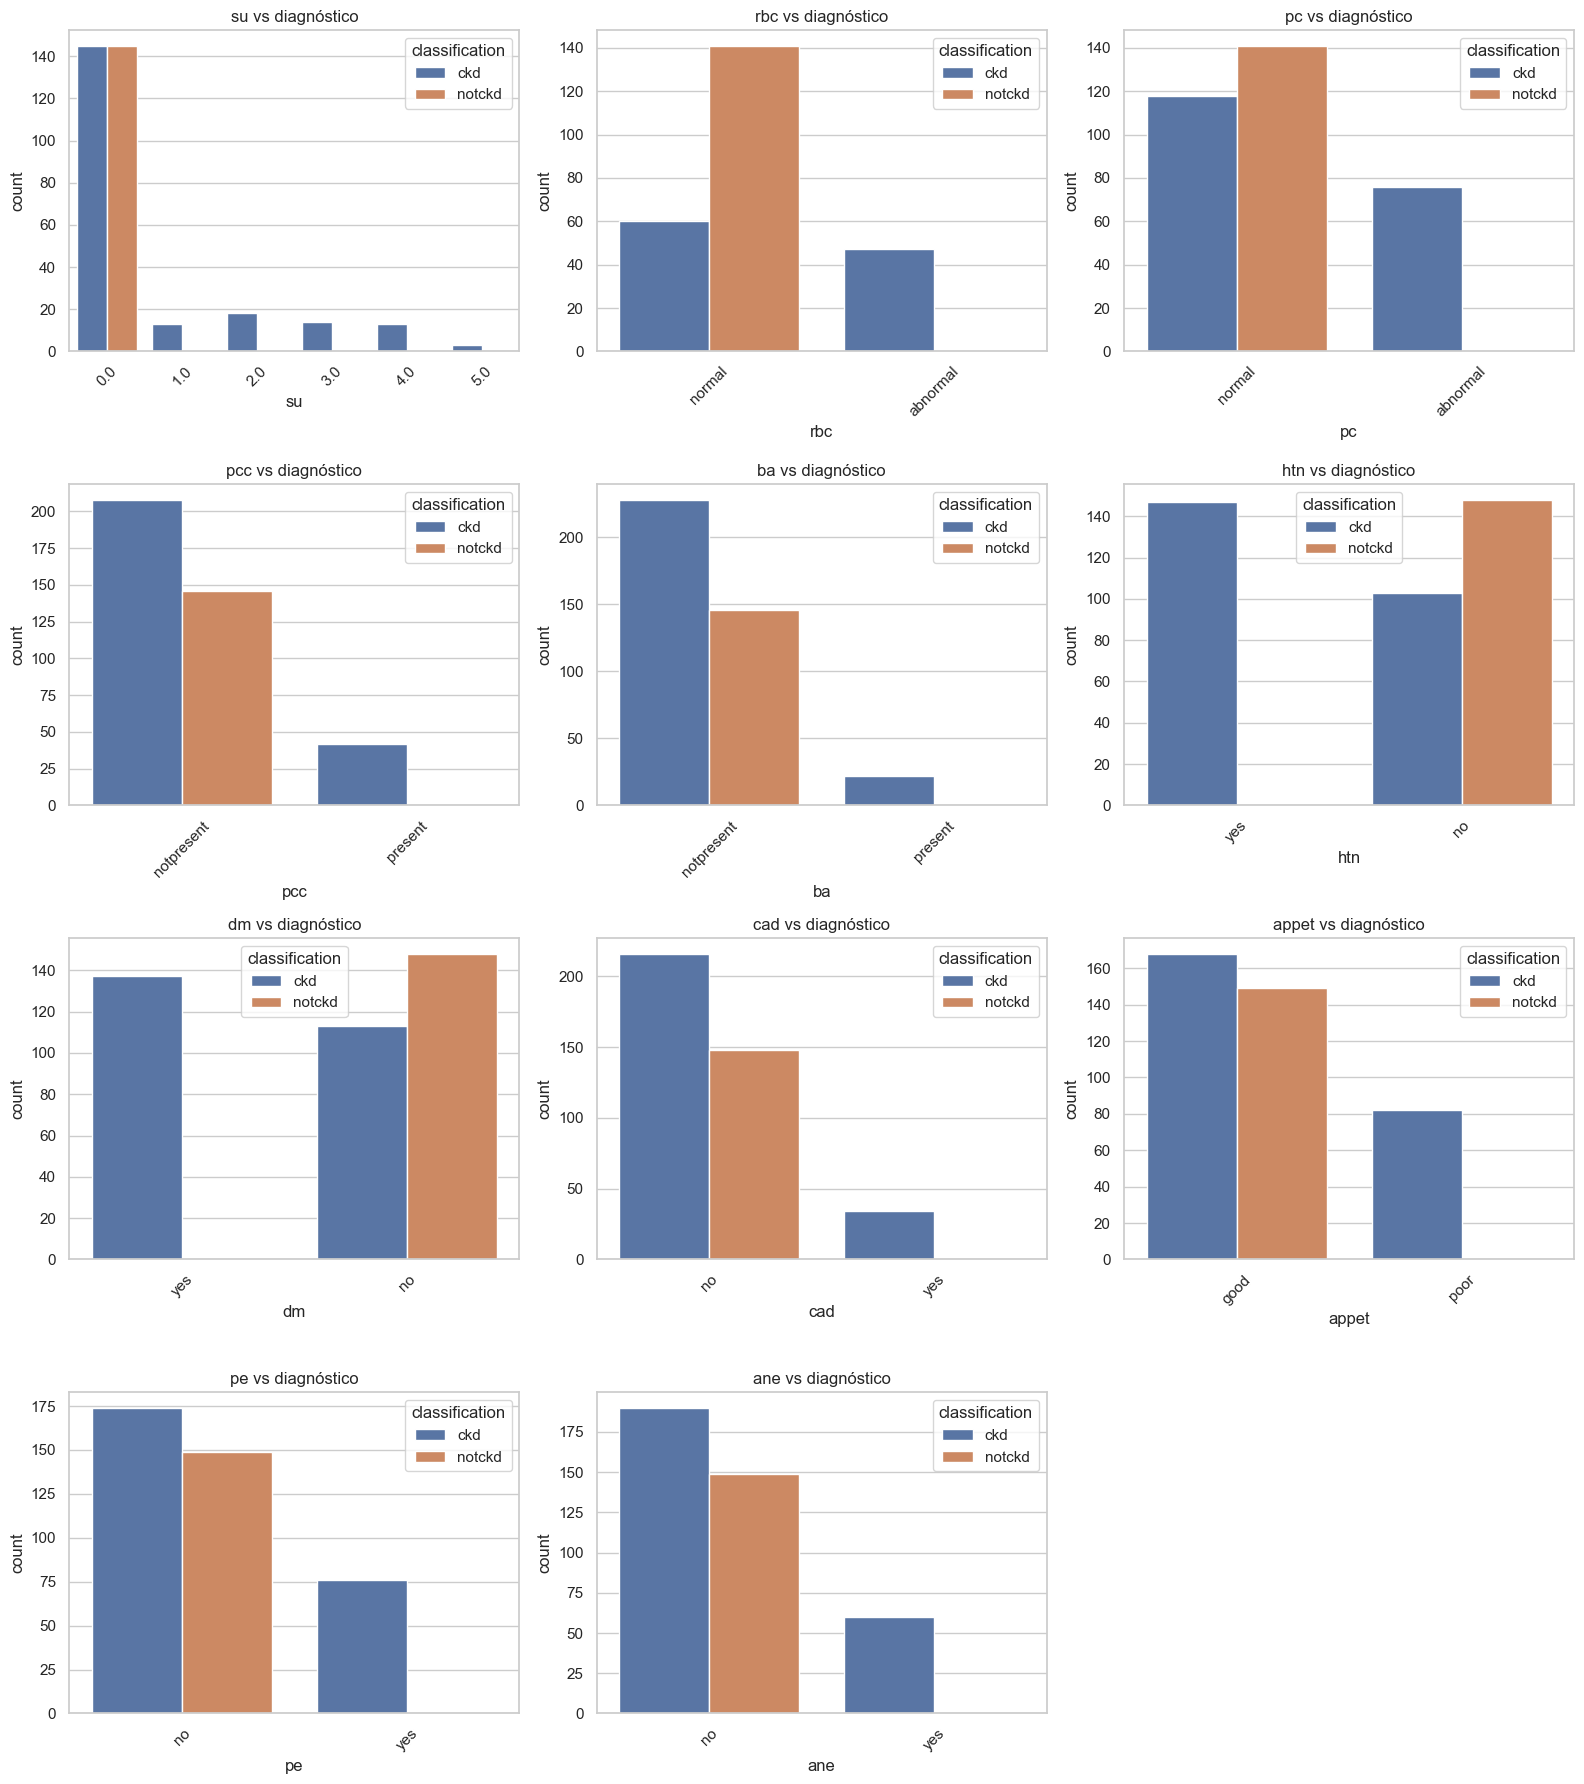

In [22]:
# Se cruza cada variable discreta contra el diagnóstico.
discretas_sin_clase = [v for v in discretas if v != 'classification']

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.ravel()

for i, v in enumerate(discretas_sin_clase):
    sns.countplot(data=df, x=v, hue='classification', ax=axes[i])
    axes[i].set_title(f'{v} vs diagnóstico')
    axes[i].tick_params(axis='x', rotation=45)

# Se apaga el recuadro sobrante (14 variables en una malla de 15)
for j in range(len(discretas_sin_clase), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# Tabla cruzada en porcentajes: de cada nivel, qué porcentaje resultó enfermo.
# normalize='index' calcula el porcentaje por fila.
for v in discretas_cat:
    if v == 'classification':
        continue
    tabla = pd.crosstab(df[v], df['classification'], normalize='index') * 100
    print(f'--- {v} (% por nivel) ---')
    print(tabla.round(1).to_string())
    print()

--- rbc (% por nivel) ---
classification    ckd  notckd
rbc                          
abnormal        100.0     0.0
normal           29.9    70.1

--- pc (% por nivel) ---
classification    ckd  notckd
pc                           
abnormal        100.0     0.0
normal           45.6    54.4

--- pcc (% por nivel) ---
classification    ckd  notckd
pcc                          
notpresent       58.8    41.2
present         100.0     0.0

--- ba (% por nivel) ---
classification    ckd  notckd
ba                           
notpresent       61.0    39.0
present         100.0     0.0

--- htn (% por nivel) ---
classification    ckd  notckd
htn                          
no               41.0    59.0
yes             100.0     0.0

--- dm (% por nivel) ---
classification    ckd  notckd
dm                           
no               43.3    56.7
yes             100.0     0.0

--- cad (% por nivel) ---
classification    ckd  notckd
cad                          
no               59.3    40.7
yes  

In [24]:
# Las discretas numéricas se comparan con su media por grupo
df.groupby('classification')[discretas_num].mean().T.round(3)

classification,ckd,notckd
su,0.767,0.0


**Observaciones:**

- En **las 10 variables binarias**, el nivel "positivo" correspondea **100% de pacientes con ckd**. Es decir, si un paciente tiene `htn = yes`, `dm = yes`, `ane = yes`, `pe = yes`, `appet = poor`, `rbc = abnormal`, `pc = abnormal`, `pcc = present`, `ba = present` o `cad = yes`, está enfermo sin excepción.

- Lo mismo ocurre con `al` y `su`: su media en el grupo `notckd` es exactamente **0.000**. Ningún paciente sano presenta albúmina ni azúcar en orina.

- `sg` (densidad urinaria) baja en los enfermos (1.014 vs 1.022) y `bp` sube ligeramente (79.6 vs 71.4 mmHg): ambos coinciden con lo esperado clínicamente.

## **5. Análisis de Valores Faltantes**

No importa solo *cuántos* faltan, sino **si faltan al azar o no**. Si la ausencia depende del
diagnóstico, eliminar las filas incompletas distorsionaría el dataset.

In [25]:
# Faltantes por variable, desglosados por diagnóstico
faltantes = pd.DataFrame({
    'pct_total'  : (df.isna().mean() * 100).round(1),
    'pct_ckd'    : (df[df['classification'] == 'ckd'].isna().mean() * 100).round(1),
    'pct_notckd' : (df[df['classification'] == 'notckd'].isna().mean() * 100).round(1),
})

faltantes.sort_values('pct_total', ascending=False)

,pct_total,pct_ckd,pct_notckd
rbc,38.0,57.2,6.0
rc,32.8,49.6,4.7
wc,26.5,39.6,4.7
pot,22.0,33.2,3.3
sod,21.8,32.8,3.3
pcv,17.8,26.8,2.7
pc,16.2,22.4,6.0
hemo,13.0,18.4,4.0
su,12.2,17.6,3.3
sg,11.8,16.8,3.3


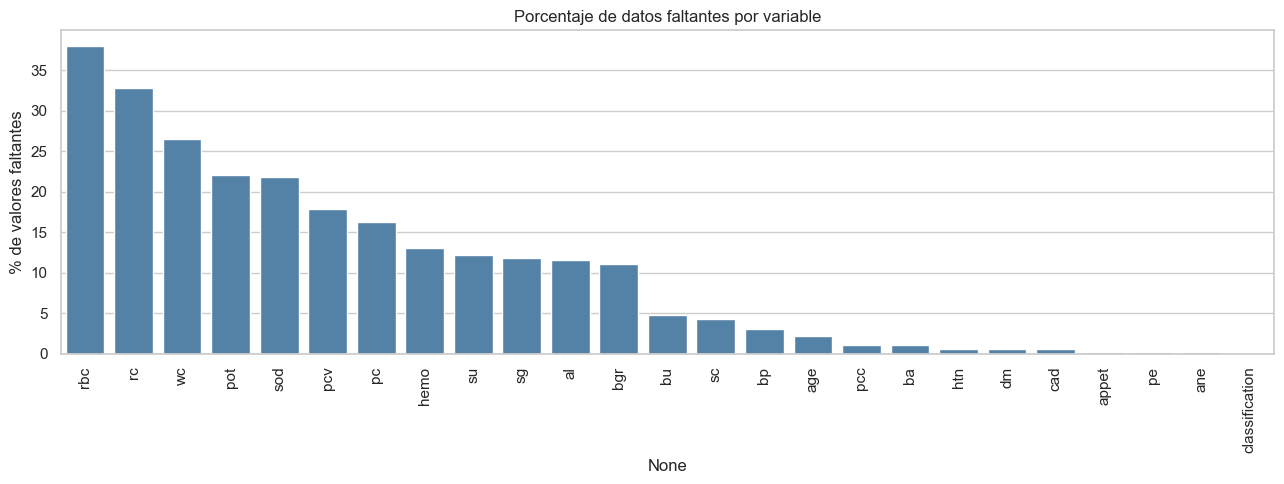

In [26]:
# Gráfica del porcentaje de faltantes por variable
orden = faltantes.sort_values('pct_total', ascending=False).index

plt.figure(figsize=(13, 5))
sns.barplot(x=orden, y=faltantes.loc[orden, 'pct_total'], color='steelblue')
plt.xticks(rotation=90)
plt.ylabel('% de valores faltantes')
plt.title('Porcentaje de datos faltantes por variable')
plt.tight_layout()
plt.show()

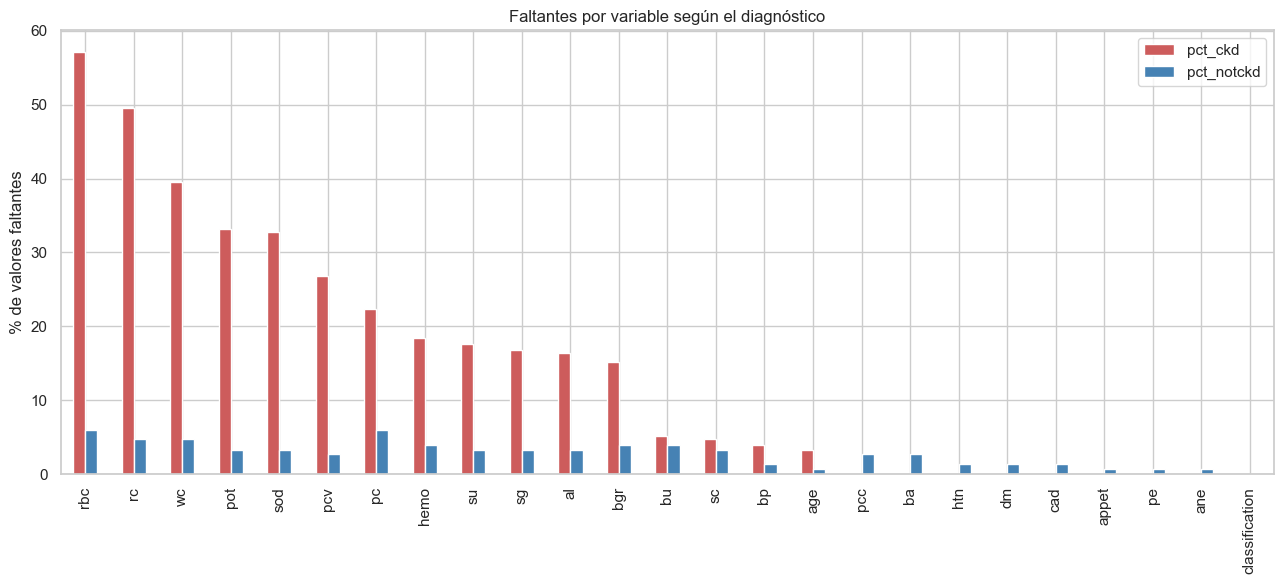

In [27]:
# Comparación de faltantes entre enfermos y sanos, deseando barras del mismo tamaño
faltantes.loc[orden, ['pct_ckd', 'pct_notckd']].plot(kind='bar', figsize=(13, 6),
                                                     color=['indianred', 'steelblue'])
plt.ylabel('% de valores faltantes')
plt.title('Faltantes por variable según el diagnóstico')
plt.tight_layout()
plt.show()

**Observaciones:**

- Solo **158 de 400** filas están completas en las 25 variables, y **203 de 400** considerando únicamente las continuas.

- Es necesario imputar los datos faltantes en la etapa de modelado.

## **6. Análisis de Correlación entre Variables Continuas**

La Red Bayesiana Gaussiana se construye a partir de la matriz de correlación, así que esta
sección muestra directamente la materia prima del modelo.

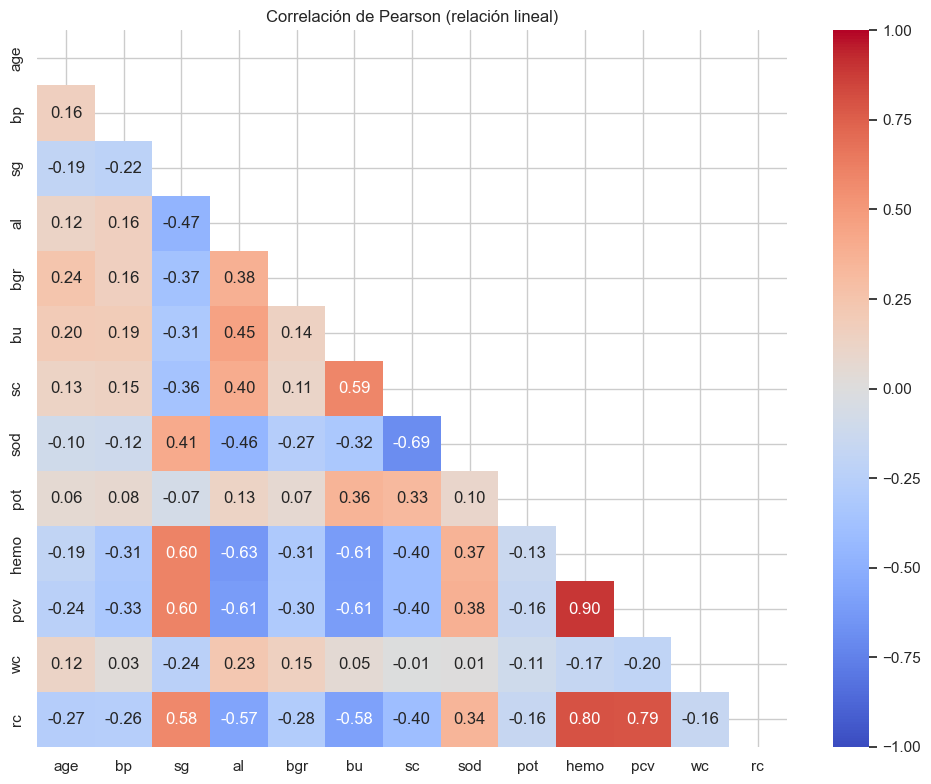

In [28]:
# Correlación de Pearson
corr_pearson = df[continuas].corr(method='pearson')

# Máscara para ocultar el triángulo superior (la matriz es simétrica)
mascara = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mascara, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Pearson (relación lineal)')
plt.tight_layout()
plt.show()

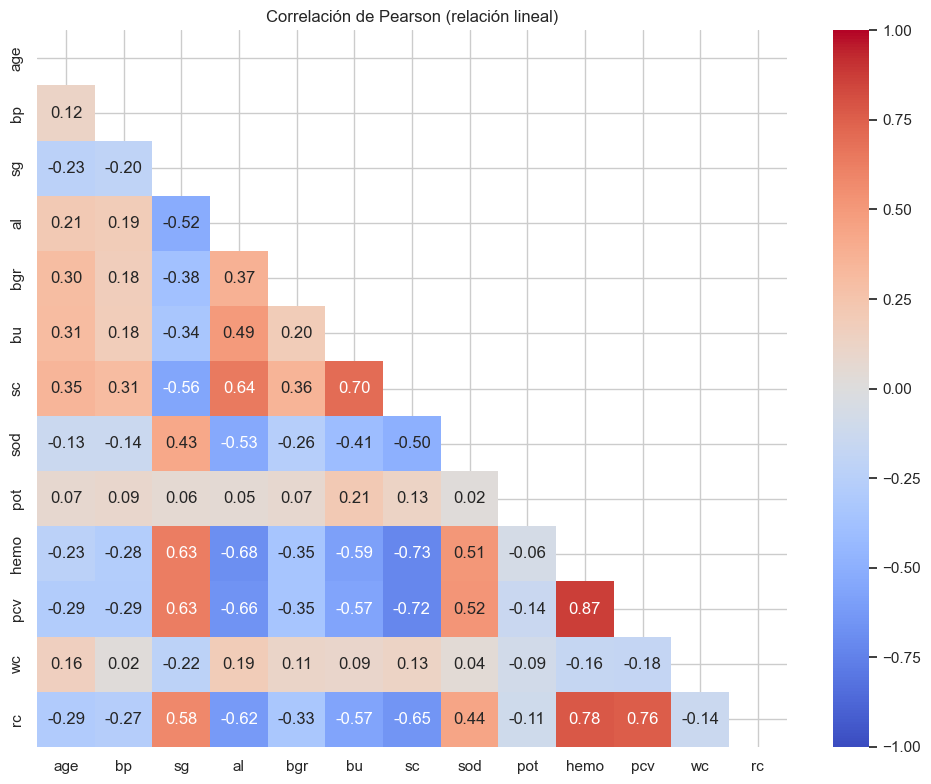

In [29]:
# Correlación de Spearman
corr_spearman = df[continuas].corr(method='spearman')

mascara = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mascara, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Pearson (relación lineal)')
plt.tight_layout()
plt.show()

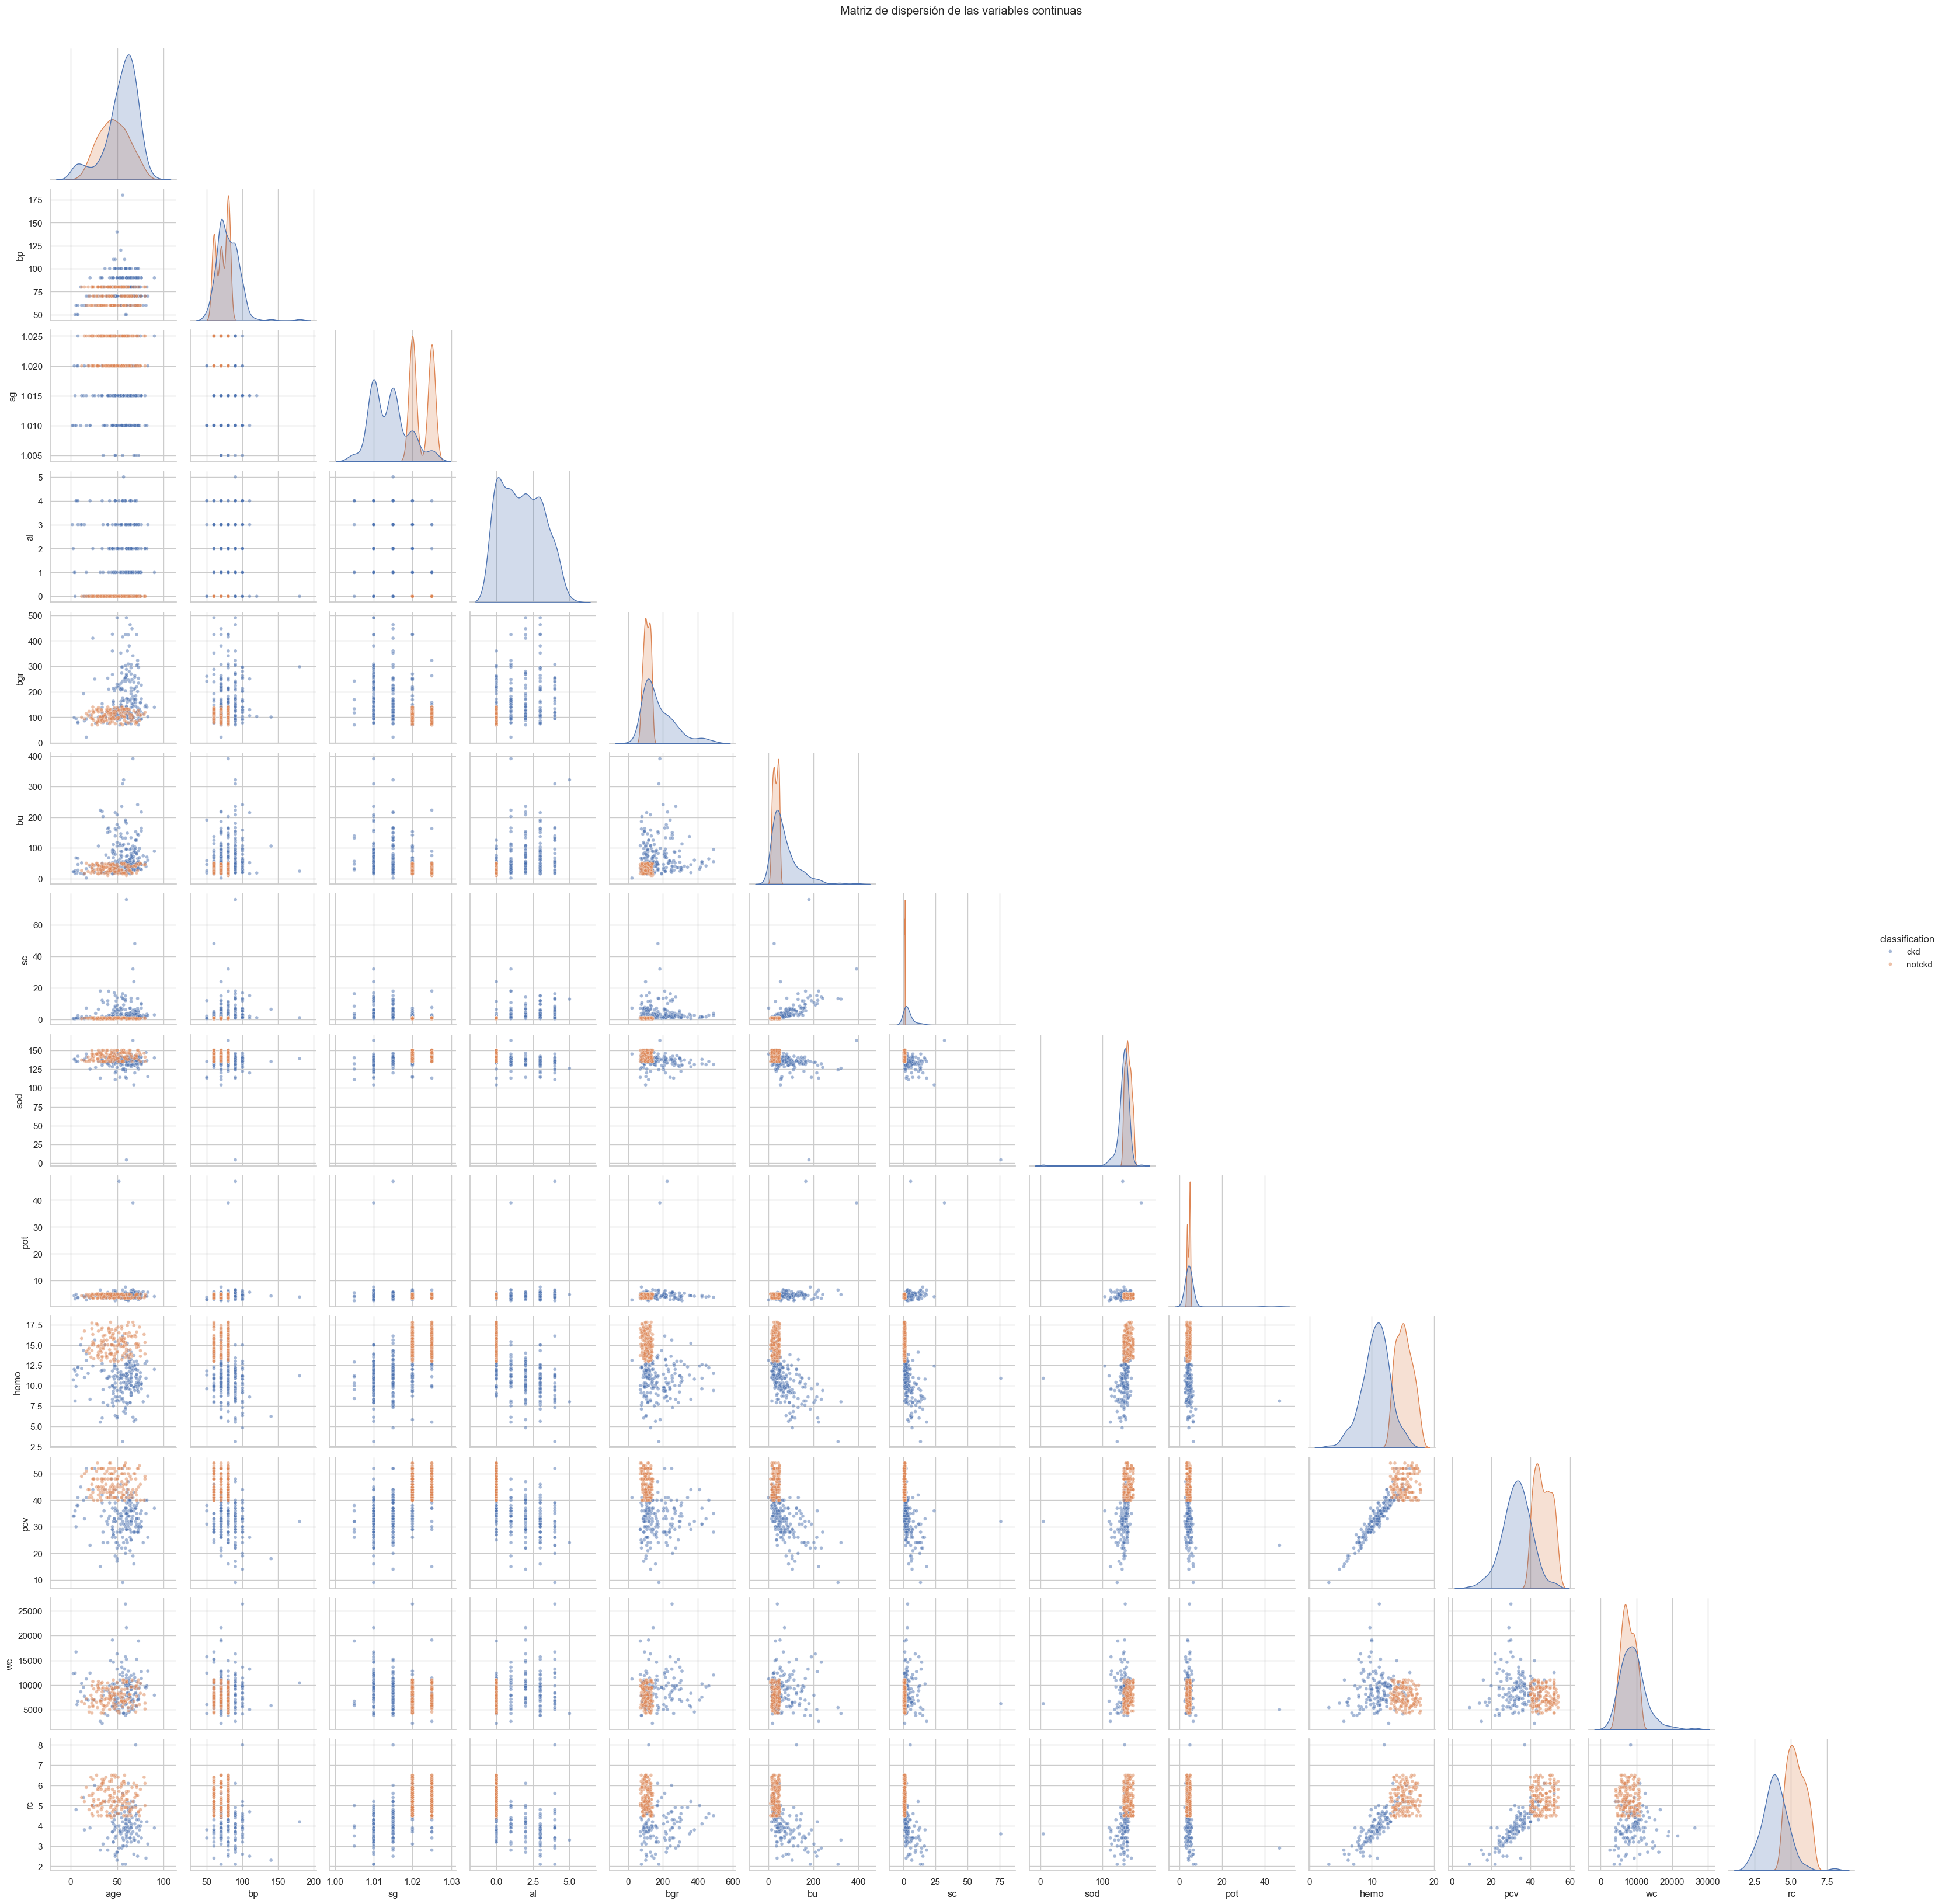

In [30]:
# Matriz de dispersión completa.
sns.pairplot(df[continuas + ['classification']], hue='classification',
             corner=True, plot_kws={'alpha': 0.5, 's': 18})
plt.suptitle('Matriz de dispersión de las variables continuas', y=1.01)
plt.show()

**Observaciones de la correlación:**

- El bloque `hemo` – `pcv` – `rc` presenta correlaciones muy altas, **miden conceptos similares**. Podrá existir redundancia al construir la red.

- `sc` y `bu` están correlacionadas (≈ 0.59): ambas son marcadores de función renal.

- En la matriz de dispersión se aprecia que muchos pares forman **dos nubes separadas** según el diagnóstico, más que una relación continua.

## **7. Resumen de Hallazgos**

**Limpieza aplicada**

| Problema detectado | Acción |
|---|---|
| `id` como columna | Eliminada (es identificador) |
| `pcv`, `wc`, `rc` como texto por el token `'\t?'` | Convertidas a numérico |

**Estructura de las variables**

- **10 continuas**: `age`, `bgr`, `bu`, `sc`, `sod`, `pot`, `hemo`, `pcv`, `wc`, `rc`. Son las únicas que entran directo a una Red Bayesiana Gaussiana.

- **15 discretas**: `bp`, `sg`, `al`, `su` y las 11 categóricas (incluyendo el diagnóstico).

**Puntos a considerar para el modelado**

1. **Faltantes no aleatorios.** Se deberá imputar los valores faltantes sobre las variables continuas.

2. **Normalidad parcial.** Ninguna variable es normal a nivel global, pero al separar por diagnóstico varias mejoran notablemente.

3. **Redundancia en ciertos datos.** `hemo`, `pcv` y `rc` son casi la misma variable.

## **8. Exportar Base de Datos**

In [31]:
# Almacenar libería procesada
df_procesada = df_continuas

df_procesada

,age,bp,sg,al,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,48.0,80.0,1.020,1.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9


In [32]:
# Guardar librería en 'data/processed'
file_path = Path('data/processed/ckd_precessed.csv')

file_path.parent.mkdir(parents= True, exist_ok= True)

df_procesada.to_csv(file_path, index= False)

## **Dudas al profesor:**

1. ¿Consideramos todos los registros o solo aquellos enfermos, es decir `classification = ckd`?

2. ¿Las variables discretas numéricas se podrían interpretar como continuas, consideramos `age`, `bp` y `sg` como continuas?

3. ¿Imputamos datos con algún otro modelo o estrategia, eliminamos esos registros o las consideramos?